# **Entregable 2**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                             mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error)

In [3]:
df_original= pd.read_csv('heart_2022_no_nans.csv')
df= df_original.copy()

## **Visualización del Dataset**

In [4]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


## **Limpieza de nombres de columnas**

In [5]:
df.columns = ['estado' , 'sexo' , 'salud_general' , 'dias_salud_fisica' , 'dias_salud_mental' , 'ultimo_chequeo' , 'actividades_fisicas' , 'horas_sueño' , 'dientes_removidos' , 'ataque_cardiaco' , 'angina' , 'ACV' , 'asma' , 'cancer_piel' , 'EPOC' , 'trastorno_depre' , 'enfermedad_riñon' , 'artritis' , 'diabetes' , 'sordo_semisordo' , 'ciego_semiciego' , 'dif_concentracion' , 'dif_caminar' , 'dif_vestirduchar' , 'dif_encargo' ,'estado_fumador' , 'uso_cigarroelect' , 'escaner_torax' , 'categoria_etnica' , 'categoria_edad' , 'altura_metros' , 'peso_kilos' , 'bmi' , 'bebedor_alcohol' , 'prueba_VIH' , 'gripa_vac' , 'pneumo' , 'tetanos' , 'alto_riesgo_ap' , 'covid']
df.columns

Index(['estado', 'sexo', 'salud_general', 'dias_salud_fisica',
       'dias_salud_mental', 'ultimo_chequeo', 'actividades_fisicas',
       'horas_sueño', 'dientes_removidos', 'ataque_cardiaco', 'angina', 'ACV',
       'asma', 'cancer_piel', 'EPOC', 'trastorno_depre', 'enfermedad_riñon',
       'artritis', 'diabetes', 'sordo_semisordo', 'ciego_semiciego',
       'dif_concentracion', 'dif_caminar', 'dif_vestirduchar', 'dif_encargo',
       'estado_fumador', 'uso_cigarroelect', 'escaner_torax',
       'categoria_etnica', 'categoria_edad', 'altura_metros', 'peso_kilos',
       'bmi', 'bebedor_alcohol', 'prueba_VIH', 'gripa_vac', 'pneumo',
       'tetanos', 'alto_riesgo_ap', 'covid'],
      dtype='object')

Se han reemplazado los nombres de las columnas por su traduccion al español.

## **Tipos de Datos**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   estado               246022 non-null  object 
 1   sexo                 246022 non-null  object 
 2   salud_general        246022 non-null  object 
 3   dias_salud_fisica    246022 non-null  float64
 4   dias_salud_mental    246022 non-null  float64
 5   ultimo_chequeo       246022 non-null  object 
 6   actividades_fisicas  246022 non-null  object 
 7   horas_sueño          246022 non-null  float64
 8   dientes_removidos    246022 non-null  object 
 9   ataque_cardiaco      246022 non-null  object 
 10  angina               246022 non-null  object 
 11  ACV                  246022 non-null  object 
 12  asma                 246022 non-null  object 
 13  cancer_piel          246022 non-null  object 
 14  EPOC                 246022 non-null  object 
 15  trastorno_depre  

## **Duplicados**

In [7]:
#Valores duplicados
print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())


Número de filas duplicadas:
9


In [8]:
df[df.duplicated()]

,estado,sexo,salud_general,dias_salud_fisica,dias_salud_mental,ultimo_chequeo,actividades_fisicas,horas_sueño,dientes_removidos,ataque_cardiaco,...,altura_metros,peso_kilos,bmi,bebedor_alcohol,prueba_VIH,gripa_vac,pneumo,tetanos,alto_riesgo_ap,covid
5702,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.70,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
87555,Maryland,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.65,45.36,16.64,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
88402,Maryland,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.75,65.77,21.41,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
137645,New Jersey,Male,Good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.63,80.74,30.55,Yes,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
174923,Rhode Island,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,1 to 5,No,...,1.57,68.04,27.44,Yes,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
184137,South Dakota,Female,Fair,30.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.75,90.72,29.53,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
208013,Vermont,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.65,79.38,29.12,Yes,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
216362,Washington,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.80,77.11,23.71,Yes,Yes,Yes,No,"Yes, received Tdap",No,No
225974,Washington,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.93,104.33,28.00,Yes,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [9]:
df= df.drop_duplicates() #limpiamos los duplicados

In [10]:
# Comprobamos limpieza
df.duplicated().sum()

np.int64(0)

## **Análisis de variable numéricas**

Descripción Estadística de variables numéricas.

In [11]:
#Descripción estadística
df.describe()

,dias_salud_fisica,dias_salud_mental,horas_sueño,altura_metros,peso_kilos,bmi
count,246013.000000,246013.000000,246013.000000,246013.000000,246013.000000,246013.000000
mean,4.119055,4.167292,7.021312,1.705150,83.615522,28.668258
std,8.405803,8.102796,1.440698,0.106654,21.323232,6.514005
min,0.000000,0.000000,1.000000,0.910000,28.120000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.270000
50%,0.000000,0.000000,7.000000,1.700000,81.650000,27.460000
75%,3.000000,4.000000,8.000000,1.780000,95.250000,31.890000
max,30.000000,30.000000,24.000000,2.410000,292.570000,97.650000


Este resumen estadístico incluye medidas clave para seis variables cuantitativas del conjunto de datos, el cual contiene **246,022 registros**:

- **`dias_salud_fisica` y `dias_salud_mental`**  
  Representan la cantidad de días en el último mes que la persona reportó mala salud física o mental, respectivamente.  
  - Promedio de aproximadamente **4 días**, pero con una **mediana de 0**, lo que indica que más del 50% de los encuestados no reportó problemas de salud en ese periodo.  
  - Valor máximo de **30 días**, indicando presencia de personas con malestar continuo durante todo el mes.

- **`horas_sueño`**  
  Número de horas de sueño que reporta la persona por noche.  
  - Promedio de **7 horas**, considerado dentro del rango saludable.  
  - Rango desde **1 hasta 24 horas**, lo que sugiere posibles valores atípicos o errores de reporte.

- **`altura_metros` y `peso_kilos`**  
  Medidas antropométricas del individuo.  
  - Altura media: **1.70 metros**  
  - Peso medio: **83.6 kg**  
  - Se observan valores extremos: altura máxima de **2.41 m** y peso máximo de **292.57 kg**, lo que podría requerir revisión o limpieza.

- **`bmi` (índice de masa corporal)**  
  Calculado con base en el peso y la altura.  
  - Promedio de **28.7**, clasificado como **sobrepeso** según la OMS.  
  - Rango de **12.0 a 97.65**, que incluye tanto casos de bajo peso como de obesidad extrema, posibles outliers o errores.

Variables numéricas en el Datatset.

In [12]:
num_cols = df.select_dtypes(include="number").columns
num_cols

Index(['dias_salud_fisica', 'dias_salud_mental', 'horas_sueño',
       'altura_metros', 'peso_kilos', 'bmi'],
      dtype='object')

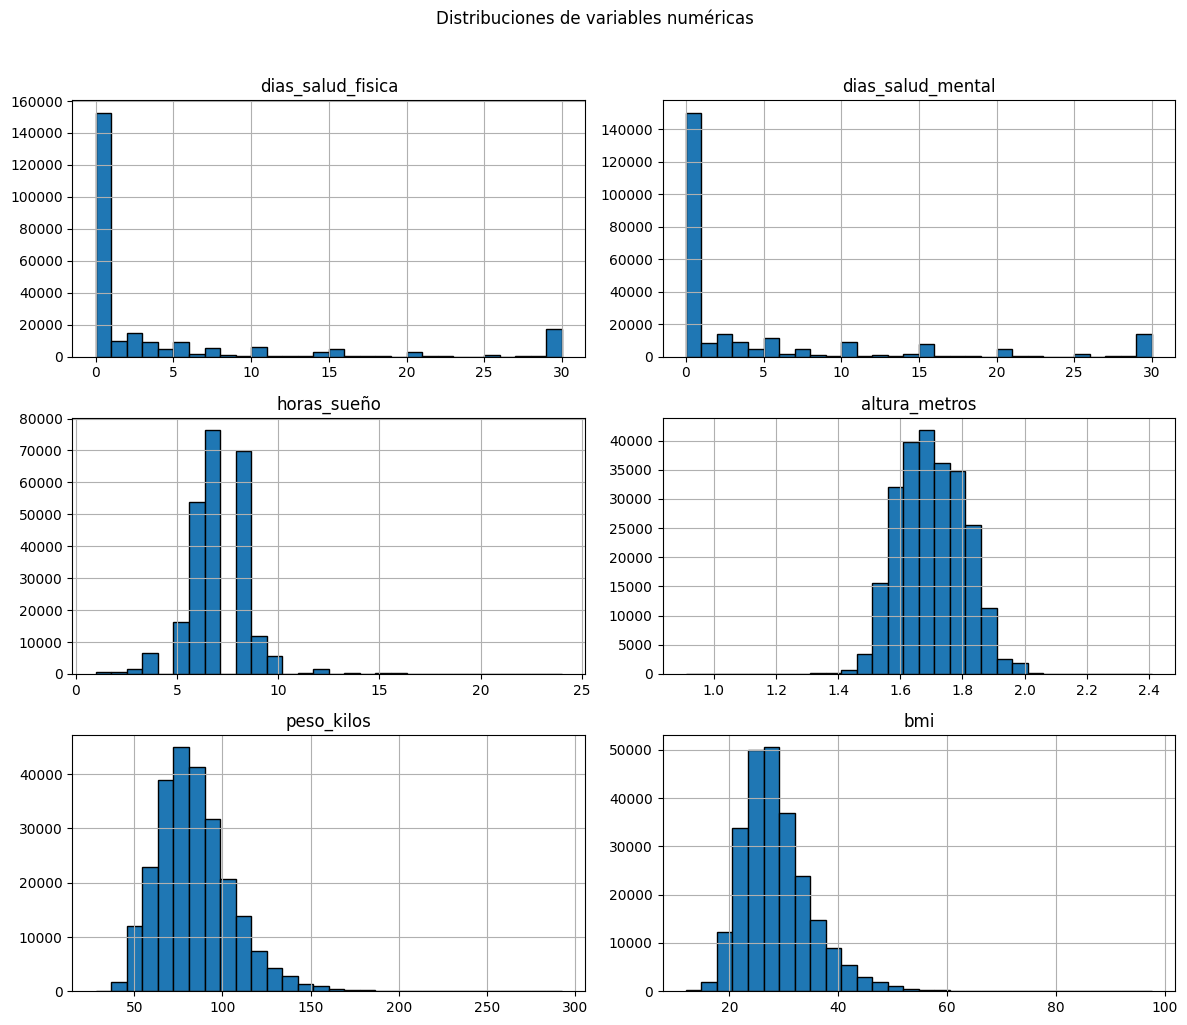

In [13]:
# Histograma para distribución de variables numéricas
df[num_cols].hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.suptitle("Distribuciones de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

 Se presentan las distribuciones de seis variables numéricas clave del conjunto de datos, que permiten observar la forma de los datos y la presencia de posibles valores atípicos:

- **`dias_salud_fisica` y `dias_salud_mental`**  
  Ambas variables muestran una distribución fuertemente **asimétrica a la derecha (sesgada positiva)**, con un alto número de personas que reportan **0 días de mala salud** en el último mes. También se observa un pequeño pico en el valor **30**, lo que podría representar personas con malestar persistente o respuestas extremas.

- **`horas_sueño`**  
  La distribución tiene una forma **aproximadamente normal**, centrada entre **6 y 8 horas** por noche. Existen pocos casos extremos con menos de 4 o más de 12 horas, lo cual podría indicar hábitos poco comunes o errores.

- **`altura_metros`**  
  Presenta una **distribución simétrica y normal**, centrada alrededor de **1.7 metros**, lo esperado en una población general.

- **`peso_kilos`**  
  Exhibe una distribución **asimétrica a la derecha**, indicando que la mayoría de las personas pesan entre **60 y 100 kg**, pero existen casos con pesos significativamente mayores, que podrían ser atípicos.

- **`bmi` (índice de masa corporal)**  
  También muestra una **asimetría a la derecha**, con una concentración de individuos en rangos de sobrepeso (**25-30**) y obesidad (**>30**). Hay valores superiores a **60**, que podrían ser casos extremos o errores de digitación.


### **Análisis de Outliers**

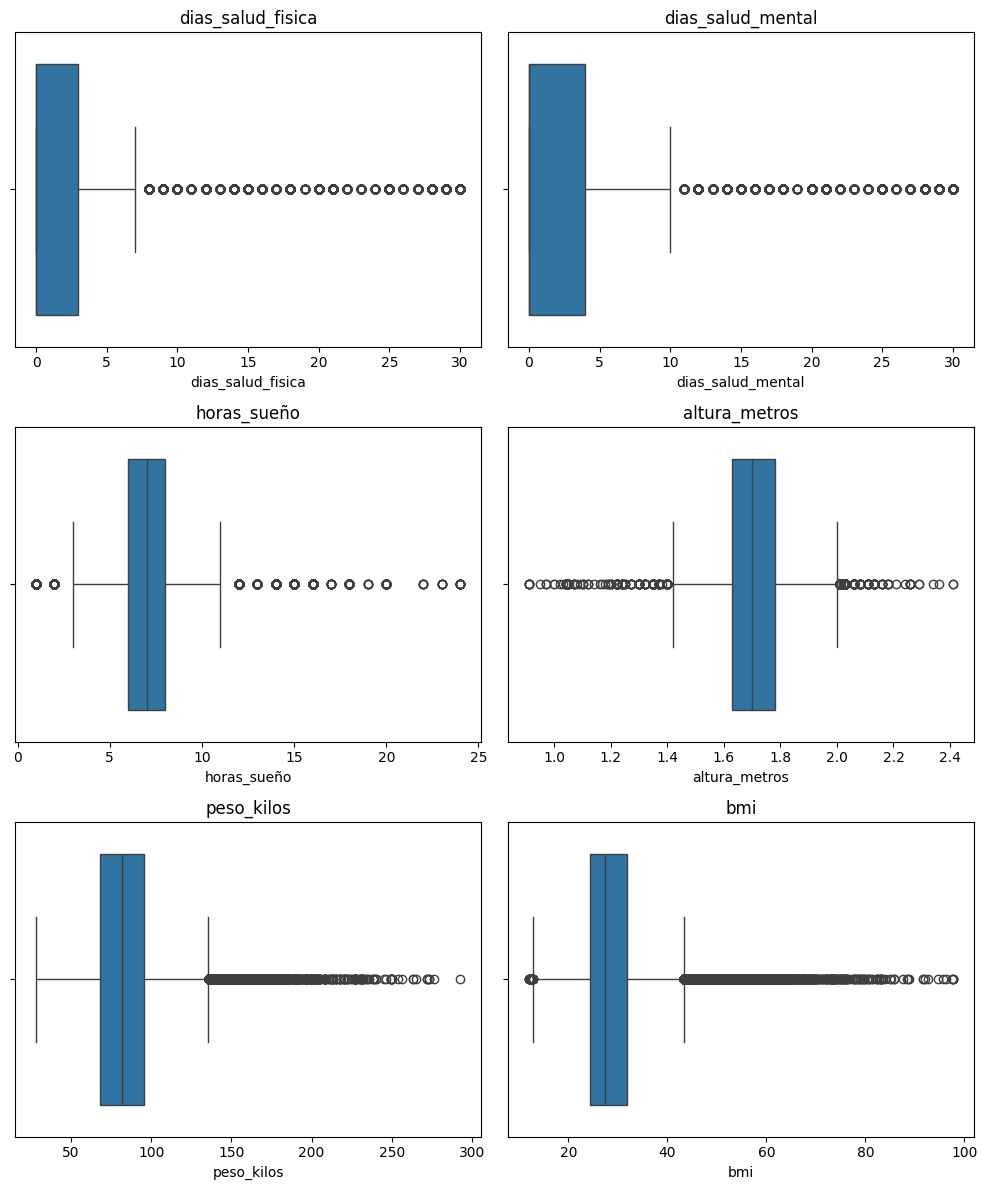

In [14]:
plots_per_row = 2
n = len(num_cols)
rows = math.ceil(n/plots_per_row)
fig, axes = plt.subplots(rows, plots_per_row, figsize=(5*plots_per_row,4*rows))
for i, col in enumerate(num_cols):
  ax = axes.flatten()[i]
  sns.boxplot(x=df[col], ax=ax).set_title(col)
for ax in axes.flatten()[n:]: fig.delaxes(ax)
plt.tight_layout()

Los diagramas de caja permiten visualizar la dispersión de los datos y la presencia de **valores atípicos** (outliers) en cada variable. A continuación, se describe lo observado en cada caso:

- **`dias_salud_fisica` y `dias_salud_mental`**  
  - La mayoría de los valores están concentrados entre 0 y 5 días.
  - Existen numerosos **valores atípicos hacia la derecha**, especialmente en **30 días**, lo que puede representar respuestas extremas (posiblemente personas con malestar todo el mes).

- **`horas_sueño`**  
  - La mediana se encuentra cerca de las 7 horas.
  - Hay outliers tanto en valores bajos (< 4 h) como altos (> 12 h), lo cual podría reflejar hábitos extremos o errores en la respuesta.

- **`altura_metros`**  
  - Tiene una distribución más simétrica.
  - Se identifican valores atípicos por debajo de 1.3 m y por encima de 2.1 m, lo cual puede ser real o deberse a errores de captura.

- **`peso_kilos`**  
  - Se identifican muchos **outliers por exceso**, especialmente en pesos mayores a 150 kg.
  - Aunque hay una tendencia normal, la dispersión sugiere una posible revisión o tratamiento de valores extremos.

- **`bmi` (índice de masa corporal)**  
  - Muestra una concentración de datos en rangos de sobrepeso y obesidad.
  - Presenta numerosos valores atípicos hacia la derecha, superando incluso los **60 puntos de IMC**, lo cual podría representar condiciones médicas graves o errores de digitación.


In [15]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
import numpy as np

class ManejoAtipicos(BaseEstimator, TransformerMixin):
    def __init__(self, metodo="iqr", estrategia="winsorizar"):
        
        self.metodo = metodo
        self.estrategia = estrategia
        self.limites_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            if self.metodo == "iqr":
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                lim_inf = Q1 - 1.5 * IQR
                lim_sup = Q3 + 1.5 * IQR
            elif self.metodo == "percentil":
                lim_inf = X[col].quantile(0.01)
                lim_sup = X[col].quantile(0.99)
            else:
                raise ValueError("Método no soportado")
            
            self.limites_[col] = (lim_inf, lim_sup)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            lim_inf, lim_sup = self.limites_[col]
            if self.estrategia == "eliminar":
                X = X[(X[col] >= lim_inf) & (X[col] <= lim_sup)]
            elif self.estrategia == "winsorizar":
                X[col] = np.where(X[col] < lim_inf, lim_inf, X[col])
                X[col] = np.where(X[col] > lim_sup, lim_sup, X[col])
        return X.reset_index(drop=True)

In [16]:
atipicos = ManejoAtipicos(metodo="iqr", estrategia="winsorizar")

# Ajustar solo con TRAIN
atipicos.fit(df[num_cols])

# Transformar TRAIN y TEST
df_num_sin_atip= atipicos.transform(df[num_cols])

In [17]:
df_num_sin_atip

,dias_salud_fisica,dias_salud_mental,horas_sueño,altura_metros,peso_kilos,bmi
0,4.0,0.0,9.0,1.60,71.67,27.99
1,0.0,0.0,6.0,1.78,95.25,30.13
2,0.0,0.0,8.0,1.85,108.86,31.66
3,5.0,0.0,9.0,1.70,90.72,31.32
4,3.0,10.0,5.0,1.55,79.38,33.07
...,...,...,...,...,...,...
246008,0.0,0.0,6.0,1.78,102.06,32.28
246009,0.0,7.0,7.0,1.93,90.72,24.34
246010,0.0,10.0,7.0,1.68,83.91,29.86
246011,2.0,2.0,7.0,1.70,83.01,28.66


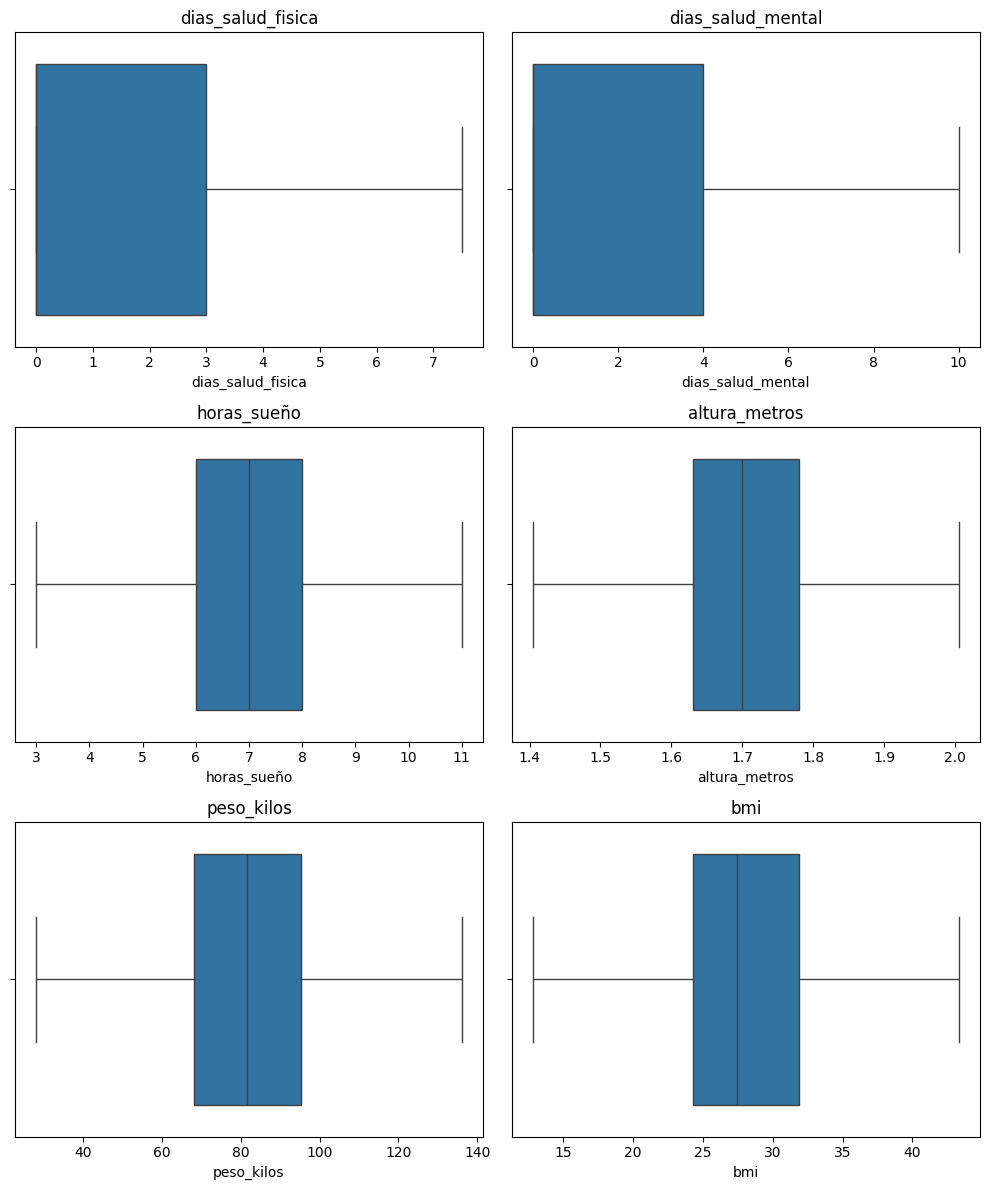

In [16]:
plots_per_row = 2
n = len(num_cols)
rows = math.ceil(n/plots_per_row)
fig, axes = plt.subplots(rows, plots_per_row, figsize=(5*plots_per_row,4*rows))
for i, col in enumerate(num_cols):
  ax = axes.flatten()[i]
  sns.boxplot(x=df_num_sin_atip[col], ax=ax).set_title(col)
for ax in axes.flatten()[n:]: fig.delaxes(ax)
plt.tight_layout()

In [18]:
df[num_cols] = df_num_sin_atip[num_cols]

Después del tratamiento de outliers podemos observar que los datos se visualizan más compactos y con una distribución manejable.

## **Análisis de Variables Categoricas**

In [17]:
# 4. Análisis de variables categóricas
cat_cols = df.select_dtypes(include="object").columns

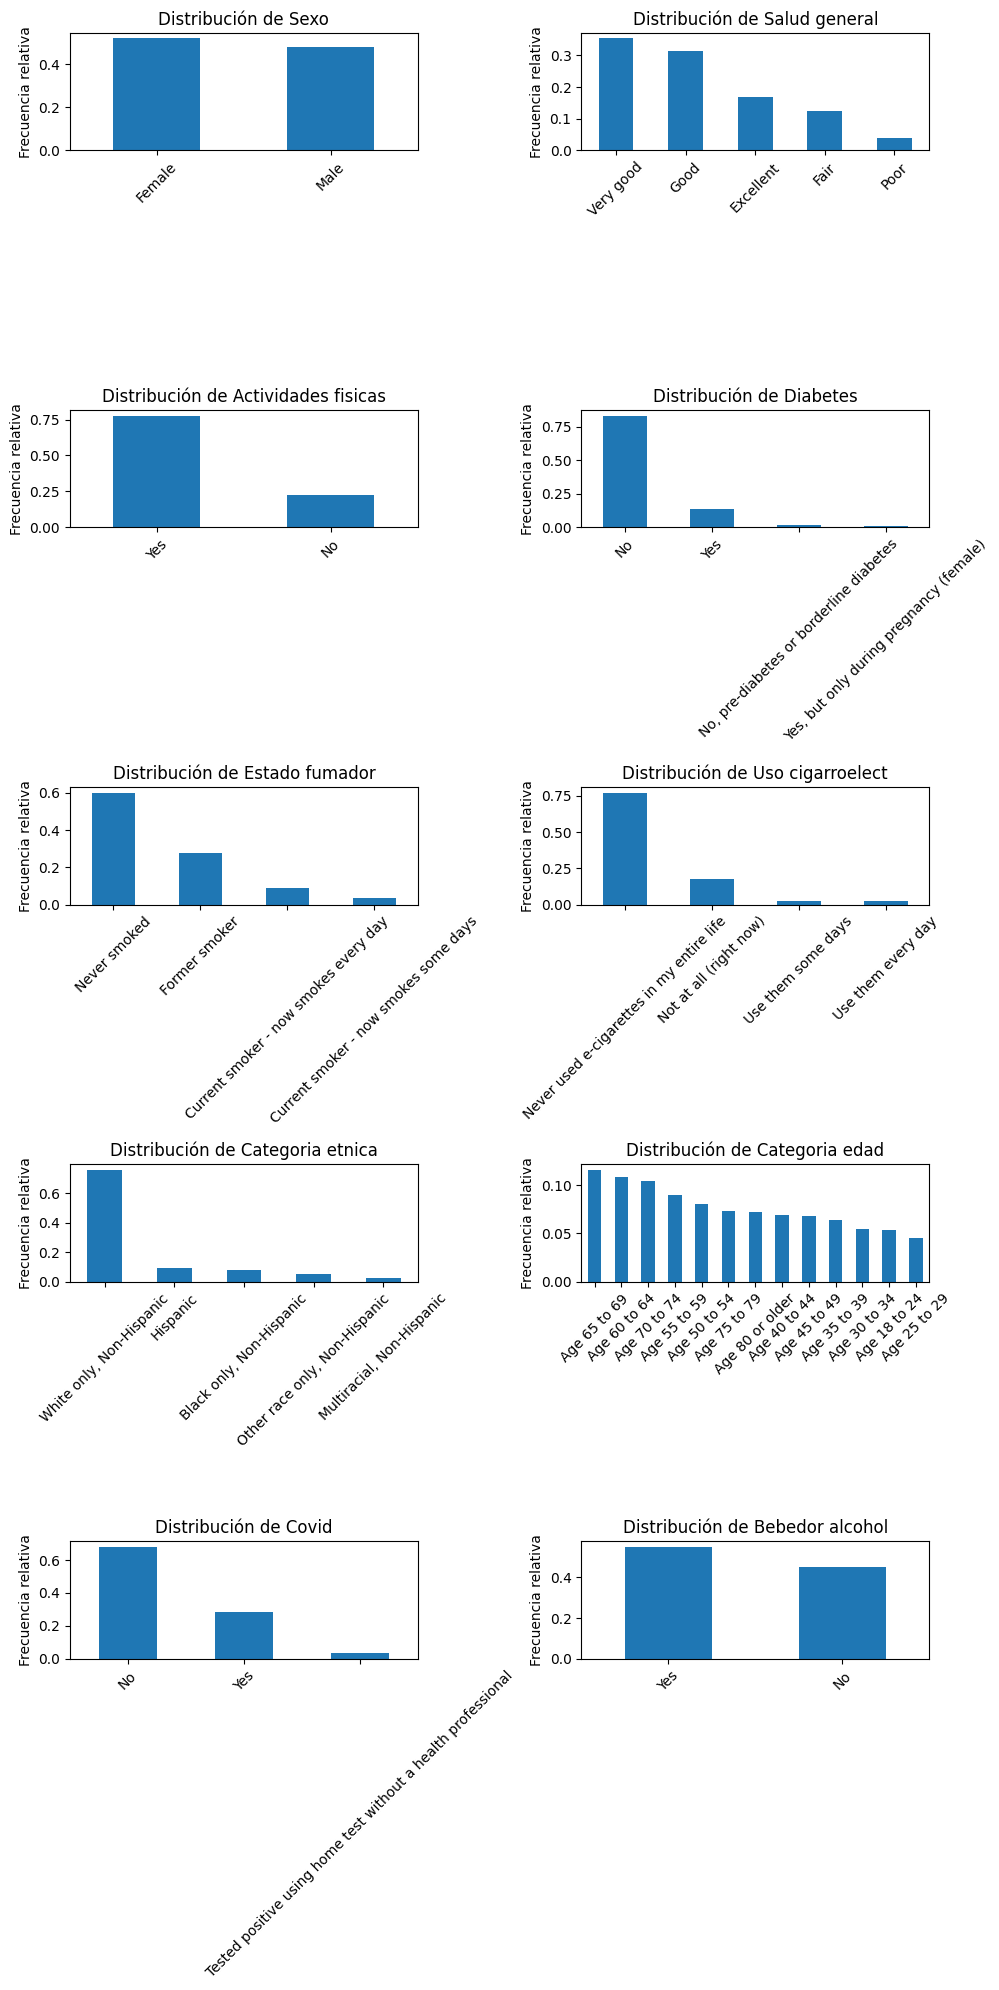

In [18]:
# Lista de variables a graficar
vars = [
    'sexo', 'salud_general', 'actividades_fisicas', 'diabetes',
    'estado_fumador', 'uso_cigarroelect', 'categoria_etnica',
    'categoria_edad', 'covid', 'bebedor_alcohol'
]

# Parámetros de la cuadrícula
per_row = 2
n = len(vars)
rows = math.ceil(n / per_row)

# Crear figura y ejes
fig, axes = plt.subplots(rows, per_row, figsize=(5*per_row, 4*rows), squeeze=False)

# Loop para generar cada gráfico
for ax, var in zip(axes.flat, vars):
    df[var].value_counts(normalize=True) \
           .plot(kind='bar', ax=ax)
    ax.set_title(f"Distribución de {var.replace('_', ' ').capitalize()}")
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia relativa')
    ax.tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos si los hay
for ax in axes.flat[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

Los gráficos muestran la distribución relativa de distintas variables categóricas relevantes para el análisis de salud. A continuación, se resume lo observado:

- **Sexo**  
  - Distribución equilibrada entre hombres y mujeres.

- **Salud general**  
  - La mayoría de los participantes se consideran con salud **“Muy buena” o “Buena”**.
  - Pocas personas se califican con salud **“Pobre”**.

- **Actividades físicas**  
  - Alrededor del **65%** de los encuestados reportan realizar actividad física.

- **Diabetes**  
  - Más de la mitad no presenta diabetes.
  - Una pequeña proporción reporta haber tenido diabetes durante el embarazo o prediabetes.

- **Estado fumador**  
  - Predominan quienes **nunca han fumado**, seguidos por **exfumadores**.
  - Los fumadores actuales son minoría.

- **Uso de cigarrillos electrónicos**  
  - Mayoría nunca ha usado cigarrillos electrónicos.
  - Bajo uso diario o frecuente.

- **Categoría étnica**  
  - Predominio de personas **blancas no hispanas**.
  - Minorías étnicas representan porcentajes mucho menores.

- **Categoría de edad**  
  - La muestra está bien distribuida, aunque destaca el grupo de edad **65–69 años** como el más representado.
  - Se observa una disminución progresiva hacia los grupos de menor edad.

- **Covid**  
  - Mayoría no ha reportado infección por COVID-19.
  - Una fracción pequeña reportó test positivo.

- **Bebedor de alcohol**  
  - Ligera mayoría indicó consumir alcohol.

In [19]:
# Reemplazar las clases por 'No'
df["diabetes"] = df["diabetes"].replace({
    "Yes, but only during pregnancy (female)": "No",
    "No, pre-diabetes or borderline diabetes": "No"
})
df['diabetes'].value_counts()

diabetes
No     212202
Yes     33811
Name: count, dtype: int64

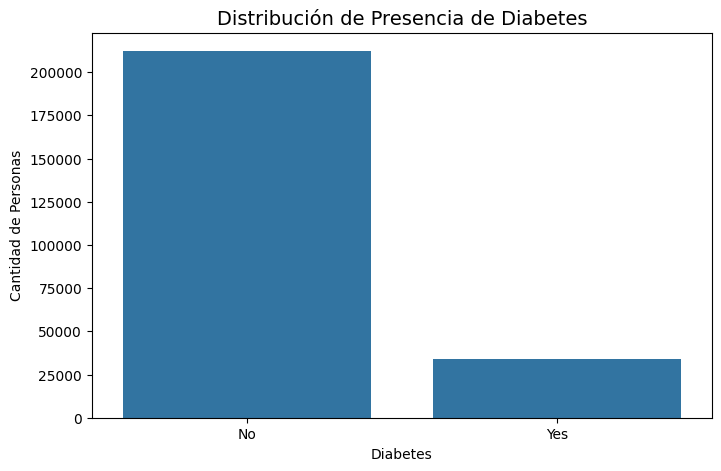

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x="diabetes", data=df)

plt.title("Distribución de Presencia de Diabetes", fontsize=14)
plt.xlabel("Diabetes")
plt.ylabel("Cantidad de Personas")
plt.show()

La variable objetivo diabetes está fuertemente desbalanceada (86.3% No vs. 13.7% Sí). Esto es un reto importante en la construcción del modelo predictivo, ya que será necesario aplicar técnicas de balanceo y usar métricas adecuadas para garantizar que el modelo pueda identificar correctamente a las personas con diabetes y no se limite a predecir siempre la clase mayoritaria.

## **Analisis bivariado**

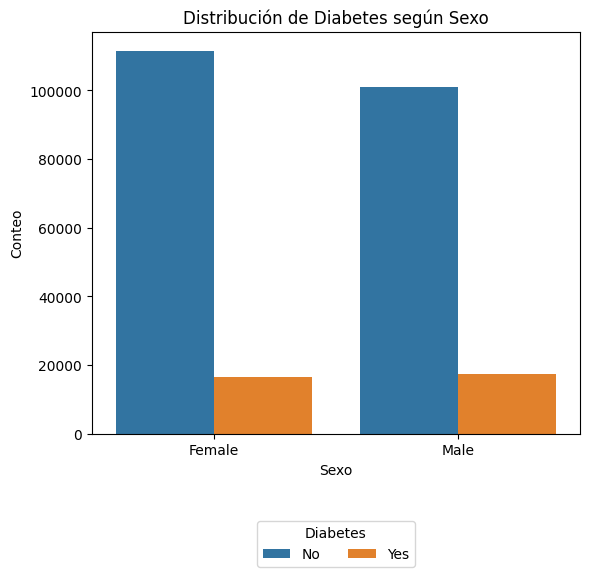

In [21]:
plt.figure(figsize=(6, 6))
sns.countplot(x='sexo', hue='diabetes', data=df)
plt.title('Distribución de Diabetes según Sexo')
plt.xlabel('Sexo')
plt.ylabel('Conteo')
# Colocar la leyenda debajo del gráfico
plt.legend(title='Diabetes',
           loc='upper center',
           bbox_to_anchor=(0.5, -0.20),
           ncol=2)
plt.tight_layout()
plt.show()

El gráfico muestra que la mayoría de los encuestados, tanto hombres como mujeres, **no presentan diabetes**. Sin embargo, se observa una **proporción ligeramente mayor de hombres con diagnóstico de diabetes** en comparación con las mujeres. Además, solo las mujeres reportan casos de diabetes **durante el embarazo**, como era de esperarse. También se identifican casos de **prediabetes o diabetes limítrofe** en ambos sexos, aunque en menor proporción.


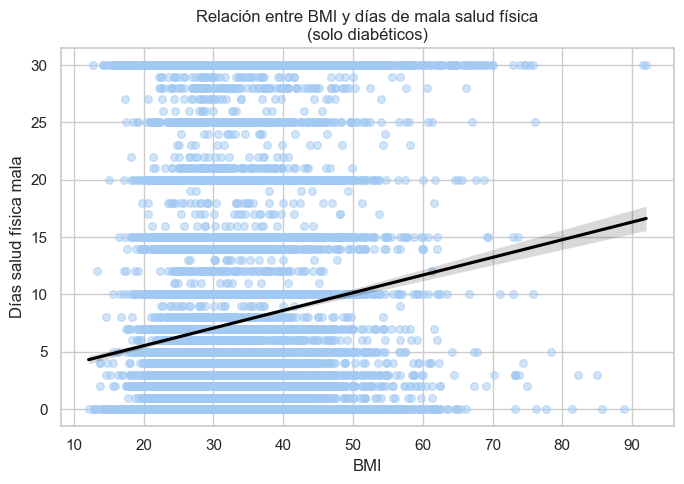

In [22]:
df_diab = df[df['diabetes']=='Yes'].copy()
sns.set(style='whitegrid', palette='pastel')
plt.figure(figsize=(7,5))
sns.regplot(
    x='bmi',
    y='dias_salud_fisica',
    data=df_diab,
    scatter_kws={'alpha':0.5, 's':30},
    line_kws={'color':'black'}
)
plt.title('Relación entre BMI y días de mala salud física\n(solo diabéticos)')
plt.xlabel('BMI')
plt.ylabel('Días salud física mala')
plt.tight_layout()
plt.show()

El gráfico muestra una **relación positiva** entre el índice de masa corporal (BMI) y los **días de mala salud física** en personas con diabetes. A medida que el BMI aumenta, también tiende a aumentar el número de días reportados con malestar físico. Aunque la dispersión es alta, la **tendencia general** sugiere que un mayor BMI podría estar asociado con una peor condición física en personas diabéticas.


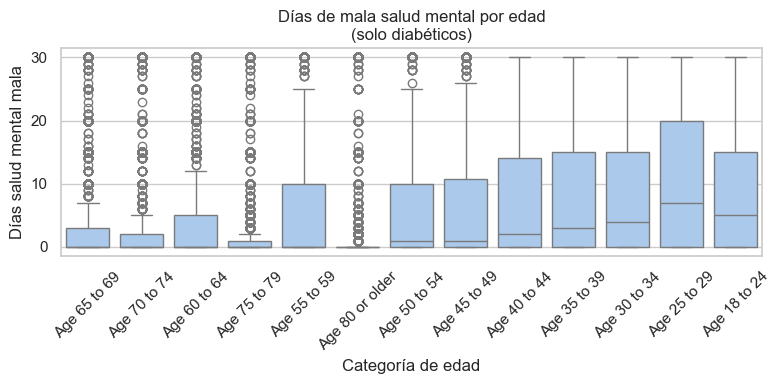

In [23]:
plt.figure(figsize=(8,4))
order_edad = df_diab['categoria_edad'].value_counts().index
sns.boxplot(
    x='categoria_edad',
    y='dias_salud_mental',
    data=df_diab,
    order=order_edad
)
plt.title('Días de mala salud mental por edad\n(solo diabéticos)')
plt.xlabel('Categoría de edad')
plt.ylabel('Días salud mental mala')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El gráfico muestra la distribución de **días de mala salud mental** entre personas con diabetes, segmentadas por categoría de edad. Se observa una **tendencia clara**: los grupos de edad más jóvenes (especialmente entre **18 y 34 años**) reportan **más días de malestar mental** en promedio, mientras que los adultos mayores tienden a reportar **menos días de afectación**. Esta diferencia sugiere una posible **vulnerabilidad emocional o psicológica mayor en personas jóvenes con diabetes**, en comparación con los grupos mayores.


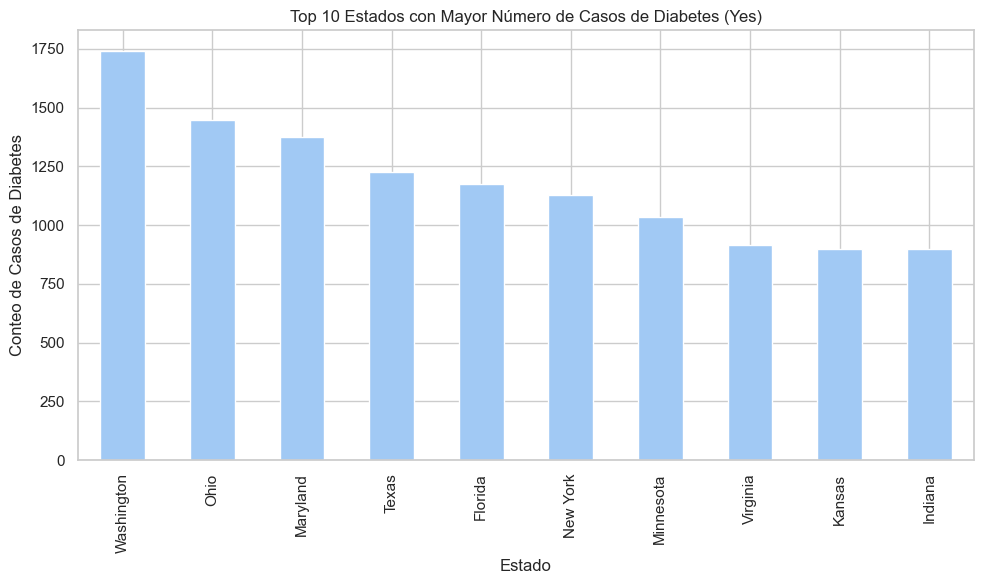

In [24]:
top10_estados = df[df['diabetes'] == 'Yes']['estado'].value_counts().head(10)

# 3. Graficar
plt.figure(figsize=(10, 6))
top10_estados.plot(kind='bar')
plt.title('Top 10 Estados con Mayor Número de Casos de Diabetes (Yes)')
plt.xlabel('Estado')
plt.ylabel('Conteo de Casos de Diabetes')
plt.tight_layout()
plt.show()

El gráfico presenta los **10 estados con mayor número de casos de diabetes diagnosticada** (respuesta "Yes"). **Washington** encabeza la lista con la mayor cantidad de personas con diabetes, seguido por **Ohio** y **Maryland**. Estos resultados permiten identificar regiones con una mayor carga de esta enfermedad, lo cual podría estar relacionado con factores sociodemográficos, acceso a servicios de salud o estilos de vida particulares de cada estado.


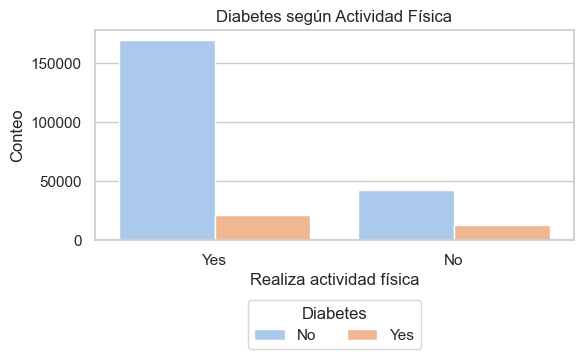

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(x='actividades_fisicas', hue='diabetes', data=df)
plt.title('Diabetes según Actividad Física')
plt.xlabel('Realiza actividad física')
plt.ylabel('Conteo')
plt.legend(
    title='Diabetes',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2
)
plt.tight_layout()
plt.show()

El gráfico muestra la relación entre la actividad física y la presencia de diabetes. Se observa que la **mayoría de las personas que realizan actividad física no tienen diabetes**. Sin embargo, también hay casos de diabetes entre quienes sí realizan ejercicio, aunque en menor proporción que entre quienes no lo hacen. En el grupo que **no realiza actividad física**, la proporción de personas con diabetes es **visiblemente mayor**, lo que sugiere una posible **asociación negativa entre la inactividad física y el diagnóstico de diabetes**.


## **Preprocesamiento de Datos**

### **Eliminar variable no relevantes para el modelo**

In [26]:
cols_drop = [
    # Moderadamente relevantes
    "sexo", "cancer_piel", "escaner_torax",
    "gripa_vac", "pneumo", "tetanos", "covid",
    
    # Poco relevantes o indirectas
    "estado", "ciego_semiciego", "sordo_semisordo",
    "dif_concentracion", "dif_caminar", "dif_vestirduchar",
    "dif_encargo", "prueba_VIH"
]

# Eliminar columnas
df = df.drop(columns=cols_drop)

## **`Diabetes` (Desbalanceada)**

In [27]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, precision_score, recall_score
)

# binarizacion de la variable Diabetes
df['diabetes'] = df['diabetes'].apply(lambda x: 1 if x == 'Yes' else 0)

# Separar X (features) e y (target)
X = df.drop(columns='diabetes')
y = df['diabetes']

# === Tipos de columnas ===
cat_cols = X.select_dtypes(include=["object","category","bool"]).columns.tolist()
num_cols = X.columns.difference(cat_cols).tolist()
categorical_idx = [X.columns.get_loc(col) for col in cat_cols]



In [28]:
categorical_idx 

[0, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 22, 23]

En este paso transformamos la variable **`diabetes`** a binaria (0 = No, 1 = Sí) 
y aplicamos **OneHotEncoder** a las variables categóricas para que el modelo pueda utilizarlas.  
Luego, estandarizamos las variables numéricas con `StandardScaler` para que todas tengan media 0 
y desviación estándar 1. Esto evita que variables con magnitudes grandes dominen el entrenamiento.


## **Partición de datos**

In [29]:
# === Split estratificado ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

## **Balance de variable objetivo con ``SMOTENC``**

In [30]:
from imblearn.over_sampling import SMOTENC
df_smote = SMOTENC(categorical_features=categorical_idx, random_state=42)

In [31]:
X_train_resampled, y_train_resampled = df_smote.fit_resample(X_train, y_train)

In [32]:
X_train_resampled.shape, y_train_resampled.shape    

((297082, 24), (297082,))

In [33]:
print("Distribución balanceada:\n", y_train_resampled.value_counts())

Distribución balanceada:
 diabetes
1    148541
0    148541
Name: count, dtype: int64


In [34]:
X_train_resampled

,salud_general,dias_salud_fisica,dias_salud_mental,ultimo_chequeo,actividades_fisicas,horas_sueño,dientes_removidos,ataque_cardiaco,angina,ACV,...,artritis,estado_fumador,uso_cigarroelect,categoria_etnica,categoria_edad,altura_metros,peso_kilos,bmi,bebedor_alcohol,alto_riesgo_ap
0,Good,0.00000,0.000000,Within past year (anytime less than 12 months ...,No,10.000000,None of them,No,Yes,No,...,Yes,Former smoker,Never used e-cigarettes in my entire life,"White only, Non-Hispanic",Age 75 to 79,1.750000,103.420000,33.670000,Yes,No
1,Excellent,0.00000,0.000000,Within past year (anytime less than 12 months ...,Yes,8.000000,None of them,No,No,No,...,No,Former smoker,Never used e-cigarettes in my entire life,"White only, Non-Hispanic",Age 75 to 79,1.700000,72.570000,25.060000,Yes,No
2,Excellent,21.00000,0.000000,Within past year (anytime less than 12 months ...,Yes,9.000000,"6 or more, but not all",Yes,No,No,...,Yes,Current smoker - now smokes every day,Not at all (right now),"White only, Non-Hispanic",Age 50 to 54,1.910000,72.570000,20.000000,Yes,No
3,Excellent,0.00000,0.000000,Within past year (anytime less than 12 months ...,Yes,7.000000,1 to 5,No,No,No,...,No,Never smoked,Not at all (right now),"White only, Non-Hispanic",Age 60 to 64,1.880000,83.910000,23.750000,Yes,No
4,Good,1.00000,4.000000,Within past year (anytime less than 12 months ...,Yes,6.000000,None of them,No,No,No,...,No,Never smoked,Never used e-cigarettes in my entire life,"White only, Non-Hispanic",Age 50 to 54,1.780000,62.600000,19.800000,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297077,Fair,16.38141,4.723718,Within past year (anytime less than 12 months ...,Yes,4.552564,All,No,No,No,...,Yes,Never smoked,Never used e-cigarettes in my entire life,"White only, Non-Hispanic",Age 65 to 69,1.708288,84.242910,28.853718,No,No
297078,Good,8.73448,0.000000,Within past year (anytime less than 12 months ...,Yes,5.746896,1 to 5,No,No,No,...,Yes,Never smoked,Never used e-cigarettes in my entire life,"White only, Non-Hispanic",Age 75 to 79,1.757593,127.010000,41.053868,No,No
297079,Very good,0.00000,0.000000,Within past year (anytime less than 12 months ...,Yes,6.576455,1 to 5,No,No,No,...,No,Former smoker,Never used e-cigarettes in my entire life,"White only, Non-Hispanic",Age 55 to 59,1.571881,63.643383,25.774032,No,No
297080,Very good,0.00000,6.279474,Within past year (anytime less than 12 months ...,Yes,6.720526,1 to 5,No,No,No,...,Yes,Never smoked,Never used e-cigarettes in my entire life,"White only, Non-Hispanic",Age 65 to 69,1.792795,102.112245,31.717140,Yes,No


## **Modelo de `Regresión Logística`**

Aplicamos **Regresión Logística** porque es un modelo interpretable y adecuado para problemas 
de clasificación binaria. Además, permite obtener probabilidades asociadas a cada paciente, lo que es útil en contextos médicos.  

Para manejar el desbalance de clases (muchos más pacientes sin diabetes que con diabetes), 
usamos el parámetro `class_weight='balanced'`.


In [35]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline


# === Preprocesador y Pipeline ===
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)
pipe_reglog= Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))
])



In [36]:
# === Entrenar ===
pipe_reglog.fit(X_train_resampled, y_train_resampled)

,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
print("Training set score: {:.3f}".format(pipe_reglog.score(X_train_resampled, y_train_resampled)))
print("Test set score: {:.3f}".format(pipe_reglog.score(X_test, y_test)))

Training set score: 0.776
Test set score: 0.718


Usamos un **Pipeline** con `StandardScaler` (numéricas) + `OneHotEncoder` (categóricas) y 
`LogisticRegression(class_weight='balanced')`.  
El objetivo clínico es **minimizar falsos negativos** (no dejar pasar diabéticos), por lo que 
**priorizamos el recall** en la clase 1 (diabéticos) y ajustamos el **umbral de decisión**.


== Métricas con threshold ==
Accuracy: 0.7175491843260527

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.72      0.81     63661
           1       0.29      0.72      0.41     10143

    accuracy                           0.72     73804
   macro avg       0.62      0.72      0.61     73804
weighted avg       0.85      0.72      0.76     73804



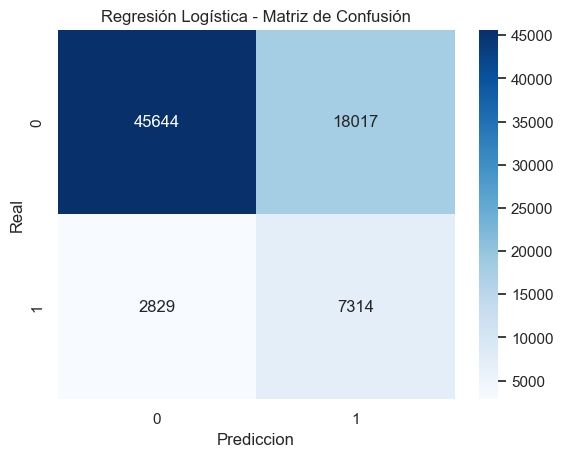

In [38]:
# === Probabilidades y baseline ===
y_proba = pipe_reglog.predict_proba(X_test)[:, 1]
y_pred = pipe_reglog.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"Regresión Logística - Matriz de Confusión")
plt.show()




- Acierta **72%** en general.  
- De cada **100 pacientes con diabetes**, detecta **~72** y se le escapan **~28** (FN = **2,829**).  
- Marca por error como diabéticos a muchos sanos (FP = **18,017**; ~**27%** de los no diabéticos).  
- Cuando dice “tiene diabetes”, solo acierta **31%** de las veces (precisión).


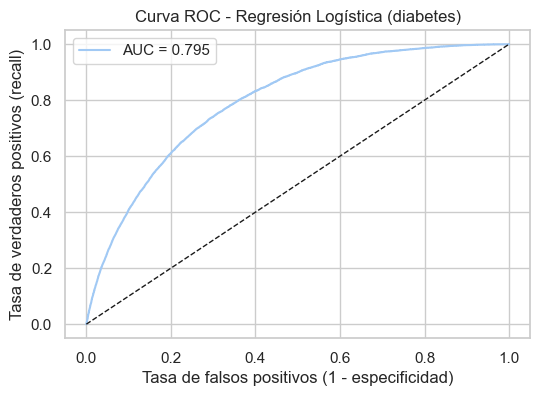

In [39]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - Regresión Logística (diabetes)")
plt.legend()
plt.show()


La curva ROC muestra que el modelo tiene buena **discriminación** entre diabéticos y no diabéticos; sin embargo, evidencia el **compromiso** entre sensibilidad (*recall*) y **tasa de falsos positivos (FPR)**: para detectar a más diabéticos hay que mover el umbral hacia zonas de mayor *recall*, aceptando más falsos positivos. En síntesis, el modelo distingue bien, pero su **utilidad clínica** depende del **umbral** elegido y del equilibrio que se acepte entre *recall* y falsos positivos.


## **Modelo de ``KNN_NeighborsClassifier``**

In [41]:
pipe_knn= Pipeline(steps=[
    ('prep', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

In [42]:
pipe_knn.fit(X_train_resampled, y_train_resampled)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


== Métricas con threshold ==
Accuracy: 0.6910736545444691

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.70      0.80     63661
           1       0.26      0.66      0.37     10143

    accuracy                           0.69     73804
   macro avg       0.59      0.68      0.58     73804
weighted avg       0.83      0.69      0.74     73804



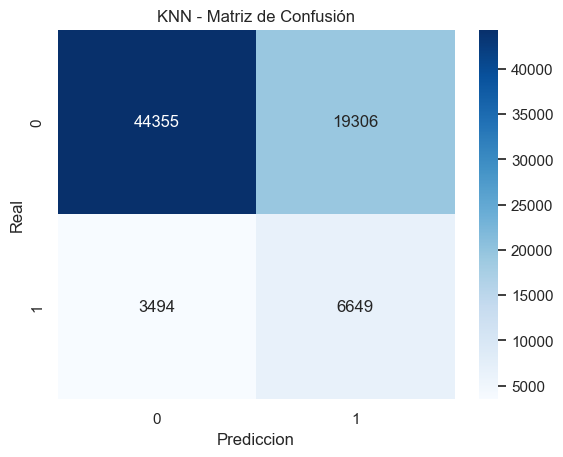


Reporte de clasificación:
               precision    recall  f1-score   support

           0      0.927     0.697     0.796     63661
           1      0.256     0.656     0.368     10143

    accuracy                          0.691     73804
   macro avg      0.592     0.676     0.582     73804
weighted avg      0.835     0.691     0.737     73804



In [ ]:
y_proba = pipe_knn.predict_proba(X_test)[:, 1]
y_pred = pipe_knn.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"KNN - Matriz de Confusión")
plt.show()


La matriz de confusión muestra el desempeño del modelo KNN en la predicción de la presencia de diabetes.  
- **Clase 0 (No diabetes):** De un total de 63,661 casos, el modelo predijo correctamente **44,355** (verdaderos negativos) pero clasificó erróneamente **19,306** como positivos (falsos positivos).  
- **Clase 1 (Diabetes):** De 10,143 casos reales, identificó correctamente **6,649** (verdaderos positivos), aunque falló en **3,494** (falsos negativos).  

Esto refleja que el modelo tiene:  
- **Alta precisión en la clase 0 (No diabetes)**, pero menor capacidad de distinguir los casos positivos.  
- **Recall de 0.66 en la clase 1**, lo que indica que logra detectar un 66% de los casos de diabetes.  
- **Accuracy general de 69%**, pero con un desbalance en las métricas entre clases.  

En conclusión, el KNN tiende a favorecer la clase mayoritaria, aunque logra detectar una proporción aceptable de casos positivos. Sin embargo, se requiere optimización o ajuste de umbral para mejorar el equilibrio entre **precisión y recall**.

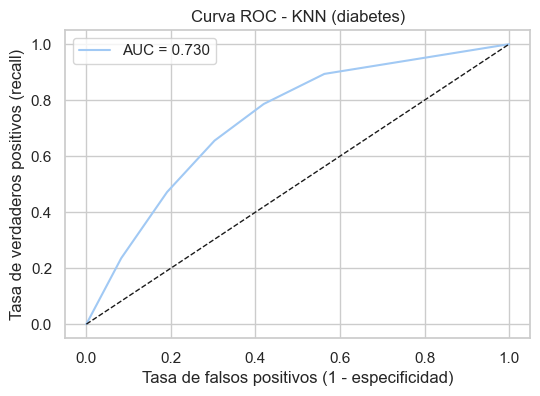

In [45]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - KNN (diabetes)")
plt.legend()
plt.show()


La curva ROC (Receiver Operating Characteristic) evalúa la capacidad del modelo KNN para diferenciar entre personas con y sin diabetes.  

- El **área bajo la curva (AUC)** es **0.73**, lo que indica un rendimiento moderado:  
  - Un AUC cercano a 0.5 implica un modelo sin poder predictivo (similar al azar).  
  - Un AUC de 0.73 sugiere que el modelo tiene una **capacidad aceptable para discriminar** entre las dos clases.  

- En la gráfica, se observa que la curva se mantiene por encima de la diagonal aleatoria (línea negra), lo cual confirma que el modelo tiene utilidad predictiva.  

En conclusión, aunque el KNN logra una discriminación razonable, el valor de AUC muestra que aún hay espacio para mejorar el modelo mediante ajustes de parámetros o el uso de algoritmos más robustos.

## **Conclusión del Avance 2**

En este segundo avance se dio continuidad al análisis iniciado en el Avance 1, incorporando mejoras metodológicas y un nuevo enfoque de modelado para la predicción de diabetes.  

### **Mejoras en la preparación de datos**
1. Se aplicó una **partición temprana (train/test split)** antes de cualquier procedimiento estadístico o de balanceo, lo cual garantiza una evaluación más justa y realista del desempeño de los modelos.  
2. Se implementó un **balanceo de clases mediante SMOTE**, con el fin de corregir el desbalance observado entre las personas con y sin diabetes. Esto permitió que el modelo tuviera una mayor oportunidad de aprender patrones de la clase minoritaria (diabetes positiva).  

### **Resultados del modelo KNN**
Se entrenó un modelo **K-Nearest Neighbors (KNN)** como alternativa a la regresión logística del Avance 1.  

- **Matriz de confusión:** el modelo logra identificar más casos positivos que la regresión logística inicial, aunque todavía presenta un número considerable de falsos positivos.  
- **Métricas principales:**  
  - **Accuracy:** 69%  
  - **Recall clase 1 (diabetes):** 0.66, lo que significa que detecta dos tercios de los casos reales.  
  - **Precisión clase 1:** 0.26, indicando que varias de sus predicciones positivas son erróneas.  
  - **AUC-ROC:** 0.73, lo que refleja una capacidad moderada de discriminación.  
  - **Average Precision (AP):** 0.25 en la curva Precision-Recall, evidenciando que el modelo aún tiene dificultades para mantener un balance adecuado entre precisión y recall.  

### **Comparación con el Avance 1**
- La **regresión logística** mostró un mejor equilibrio en precisión, pero menor recall sobre la clase positiva.  
- El **KNN**, tras el balanceo con SMOTE, mejora la **sensibilidad (recall)** en la detección de diabéticos, aunque a costa de una menor precisión.  
- Esto sugiere que el KNN puede ser útil cuando la prioridad es **detectar la mayor cantidad posible de casos de diabetes**, incluso si eso implica más falsos positivos.  

### **Próximos pasos**
1. Explorar **modelos más robustos** como Random Forest, Gradient Boosting o CatBoost, que podrían superar las limitaciones observadas en KNN.  
2. Evaluar **ajustes de hiperparámetros** en KNN (k, distancia, pesos) para optimizar el balance entre precisión y recall.  
3. Complementar con **técnicas de interpretabilidad** (SHAP, feature importance) para identificar con claridad qué variables influyen en las predicciones.  

---

## **Conclusión general**
El avance 2 marca un progreso importante al introducir balanceo de clases y un modelo alternativo al inicial. Aunque el KNN presenta limitaciones en precisión, logra un mejor recall y una capacidad aceptable de discriminación, lo que es relevante en contextos clínicos donde **detectar más casos de diabetes es prioritario**.  
El proyecto se encuentra ahora en una etapa donde la incorporación de modelos más sofisticados y técnicas de interpretación permitirá fortalecer tanto la capacidad predictiva como el valor analítico de los resultados.

